In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt


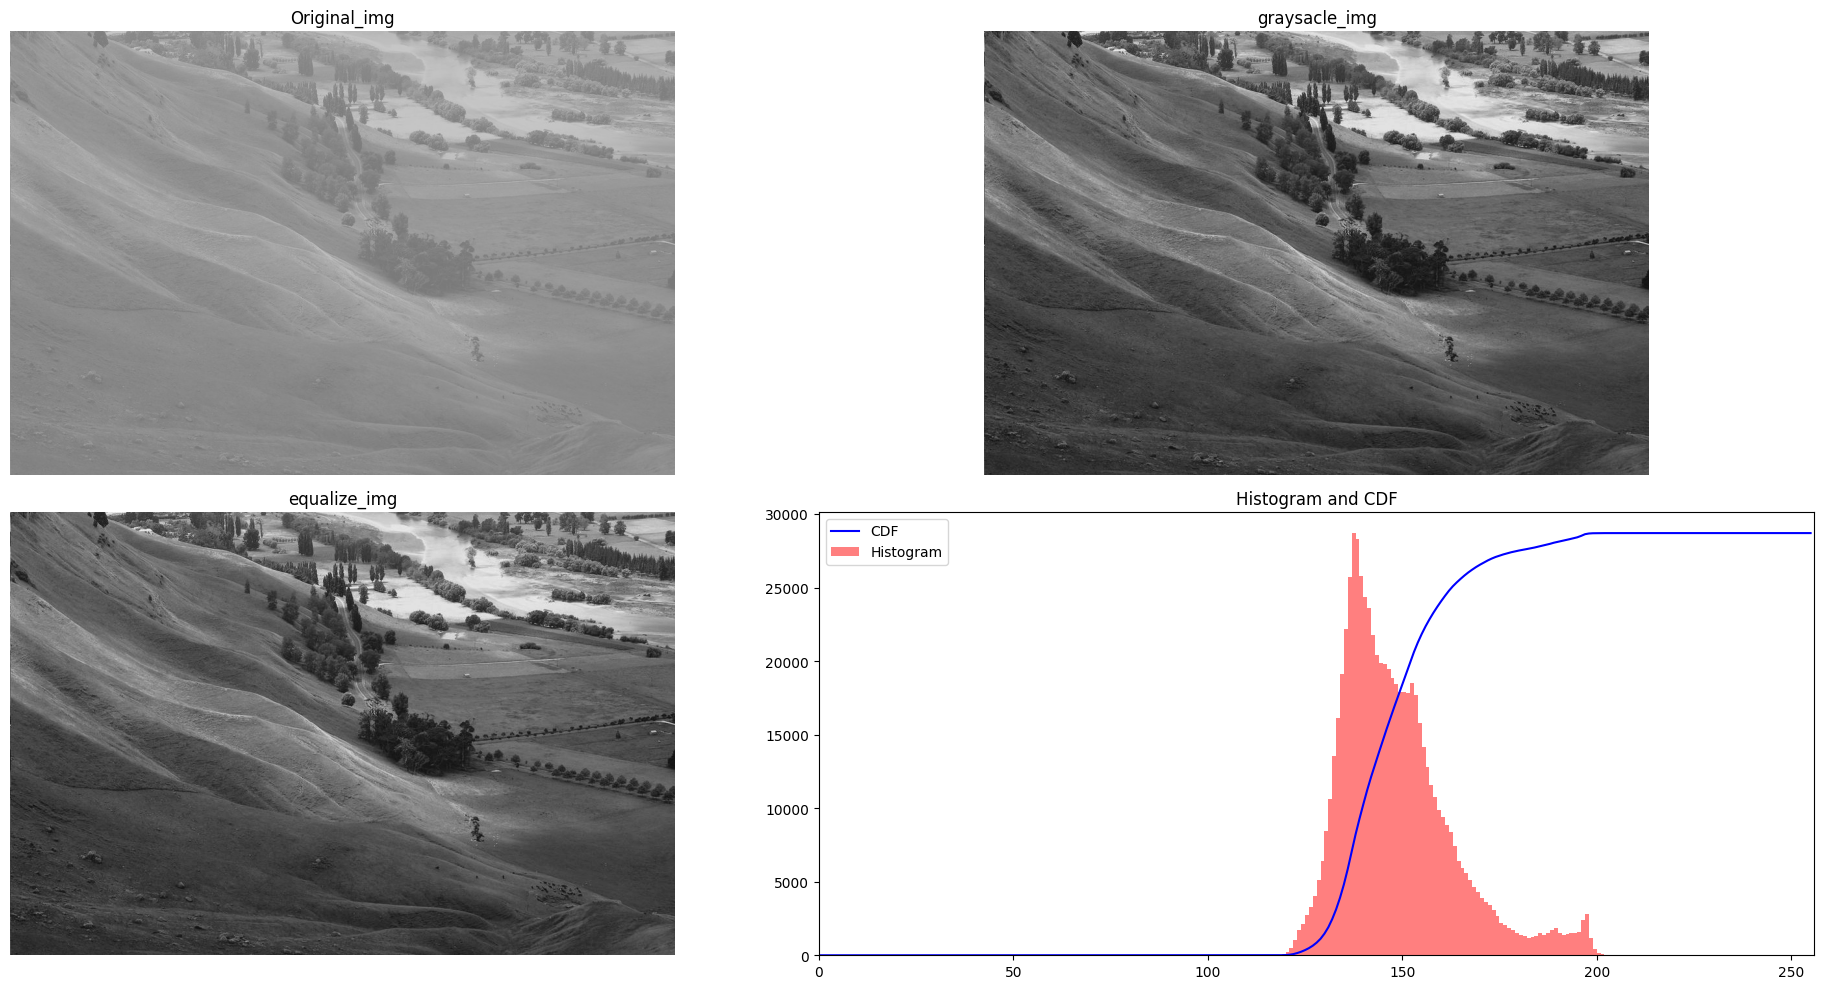

In [ ]:
image = cv.imread('unequal.jpg')
img = cv.imread('unequal.jpg',cv.IMREAD_GRAYSCALE)
#Compute Histogram and CDF
hist, bins = np.histogram(img.flatten(), 256,[0,256])
cdf = hist.cumsum()
cdf_norm =cdf*float(hist.max())/cdf.max()
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m-cdf_m.min())*255/(cdf_m-cdf_m.min())
cdf = np.ma.filled(cdf_m,0).astype('uint8')
img2 = cdf[img]
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(original_img,cv.COLOR_BGR2RGB))
plt.title('Original_img')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(img, cmap='gray')
plt.title('graysacle_img')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(img, cmap='gray')
plt.title('equalize_img')
plt.axis('off')
plt.subplot(2,2,4)
plt.plot(cdf_norm, color='b')
plt.hist(img.flatten(),256,[0,256], color='r',alpha=0.5)
plt.xlim([0,256])
plt.legend(('CDF', 'Histogram'),loc ='upper left')
plt.title('Histogram and CDF')
plt.tight_layout()
plt.show()

In [ ]:
#Contrast Limited adaptive histogram equalization


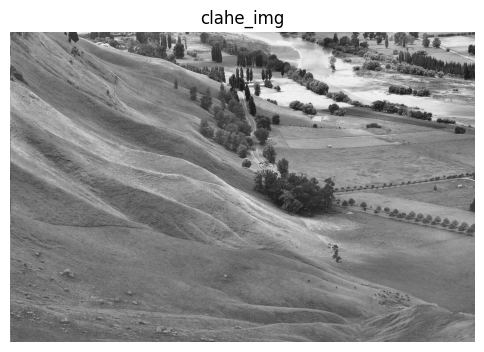

In [ ]:
image = cv.imread('unequal.jpg')
img = cv.imread('unequal.jpg',cv.IMREAD_GRAYSCALE)
clahe = cv.createCLAHE(clipLimit = 2.0, tileGridSize=(8,8))
cl1=clahe.apply(img)
cv.imwrite('clahe_2.jpg',cl1)
clahe_img=cv.imread('clahe_2.jpg',cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(6,6))
plt.imshow(clahe_img,cmap='gray')
plt.title('clahe_img')
plt.axis('off')
plt.show()